In [1]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, style_ax, country_handles, legend

In [2]:
df_enw = pd.read_parquet("0_intermediate/df_enw.parquet")

_excl    = {'FC_OTH_NSP_E', 'FC_TRA_NSP_E', 'FC_TRA_DAVI_E', 'FC_TRA_DNAVI_E'}
subs_enw = [s for s in var_groups.subs if s not in _excl]
countries = [g for g in var_groups.countries if g not in {'UK', 'ES'}]

df_enw = df_enw[df_enw.nrg_bal.isin(subs_enw) & df_enw.geo.isin(countries)].copy()

# Sector order: derived from data (alphabetical, same as 2_electrification_rates)
sectors = list(df_enw.nrg_bal.unique())

# Share of each sector within total included energy per country-year
df_enw['share_pct'] = (
    df_enw['value']
    / df_enw.groupby(['geo', 'year'])['value'].transform('sum')
    * 100
)

years = np.sort(df_enw.year.unique())

## Sektorandele af samlet energiforbrug pr. land

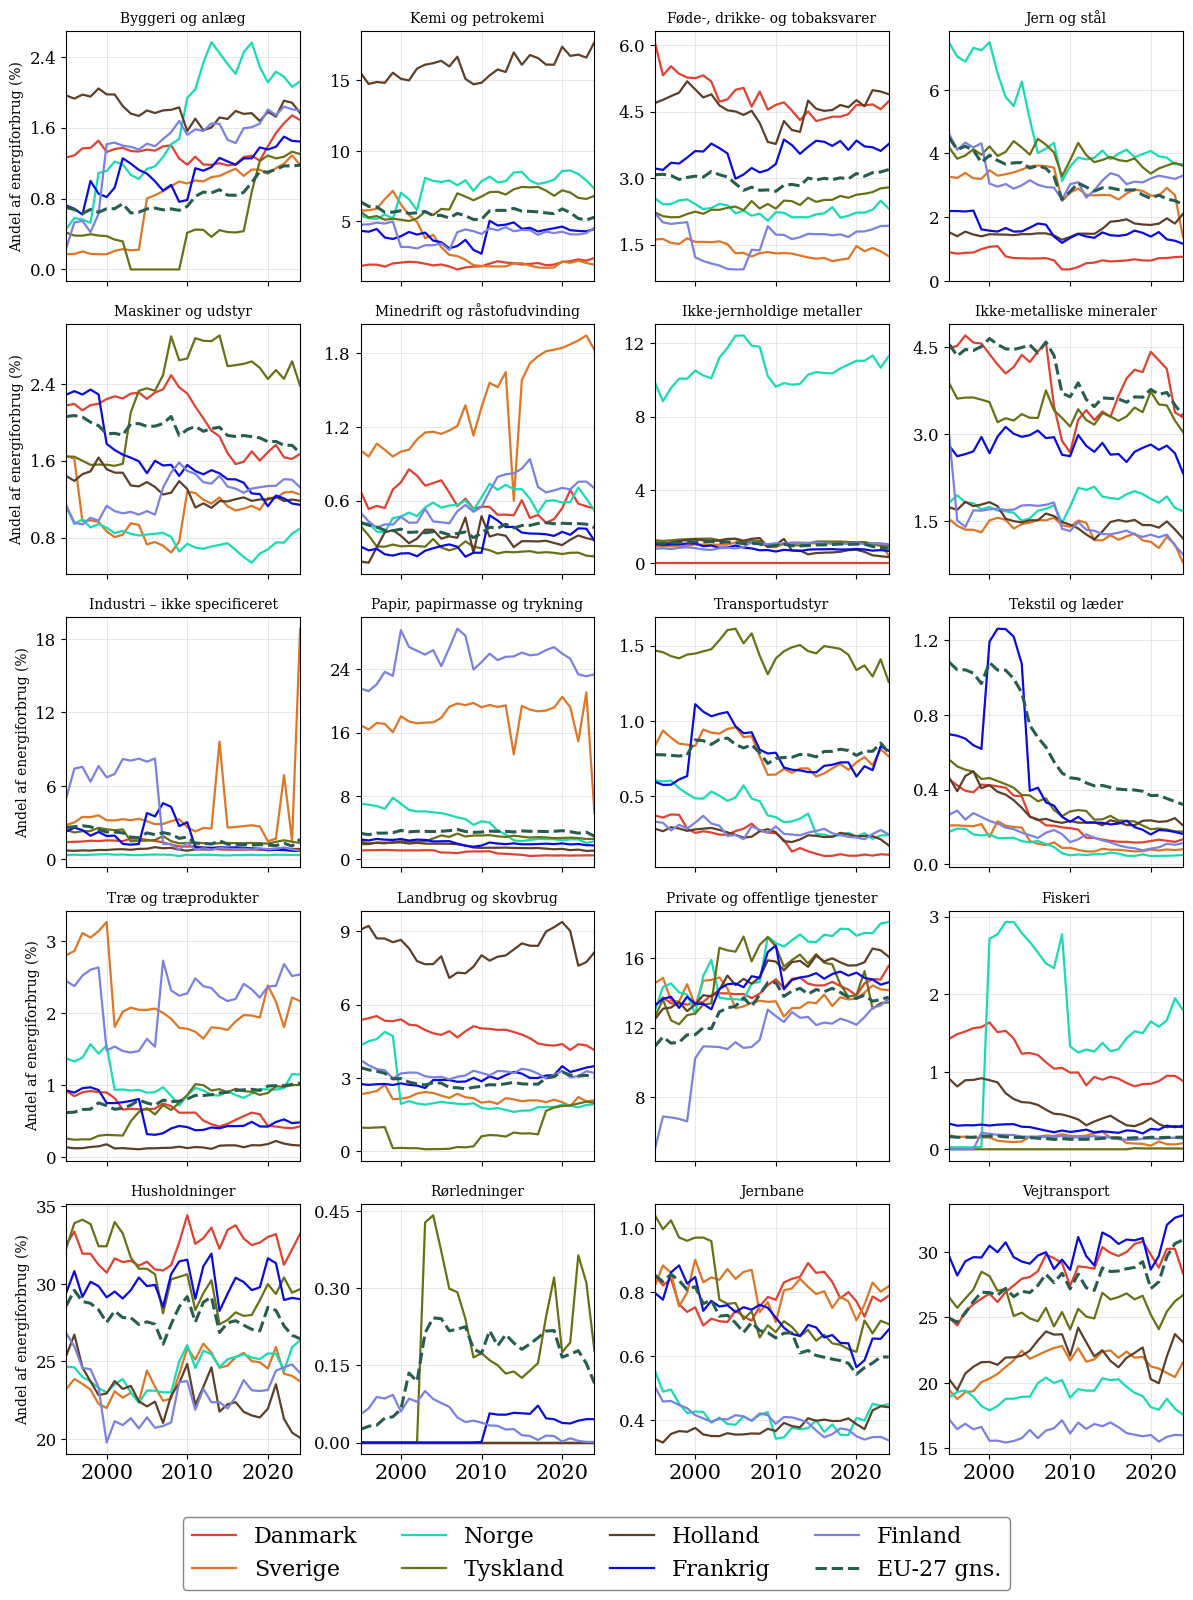

In [5]:
NCOLS = 4
NROWS = -(-len(sectors) // NCOLS)

fig, axes = plt.subplots(NROWS, NCOLS,
                         figsize=(12, NROWS * 3),
                         sharex=True)
axes_flat = axes.flatten()

for ax, sector in zip(axes_flat, sectors):
    sub = df_enw[df_enw.nrg_bal == sector]
    for geo in countries:
        s = sub[sub.geo == geo].sort_values('year')
        if s.empty:
            continue
        ax.plot(s.year, s.share_pct,
                color=PALETTE[geo], ls=STYLE[geo], lw=LW[geo])
    ax.set_title(var_groups.labels.get(sector, sector), fontsize=10)
    style_ax(ax, years, step=10)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))

for ax in axes_flat[len(sectors):]:
    ax.set_visible(False)

for ax in axes[:, 0]:
    ax.set_ylabel('Andel af energiforbrug (%)', fontsize=10)

fig.legend(handles=country_handles(countries),
           loc='lower center',
           ncols=len(countries)/2,
           frameon=True, framealpha=0.95, edgecolor='0.5', fancybox=True,
           bbox_to_anchor=(0.5, -0.07))

plt.tight_layout()
plt.show()

In [4]:
### Sanity check: sektor-andele summer til 100 % pr. land og år
totals = df_enw.groupby(['geo', 'year'])['share_pct'].sum()
summary = totals.groupby('geo').agg(['min', 'max']).round(2)
assert (summary['min'] > 99.0).all() and (summary['max'] < 101.0).all(), \
    "Andele summer ikke til ~100 %!"
print("✓ Alle landes sektorer summer til ~100 % (min/max pr. land):")
summary

✓ Alle landes sektorer summer til ~100 % (min/max pr. land):


,min,max
geo,,
DE,100.0,100.0
DK,100.0,100.0
EU27_2020,100.0,100.0
FI,100.0,100.0
FR,100.0,100.0
NL,100.0,100.0
NO,100.0,100.0
SE,100.0,100.0
